In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.simplefilter("ignore")

In [3]:
rating_df = pd.read_csv(r"C:\Users\amann\Aman\Aman\MLOPS\Project-2\Anime_Recommender_System\artifacts\raw\animelist[1].csv")

In [4]:
rating_df

,user_id,anime_id,rating,watching_status,watched_episodes
0,0,67,9,1,1
1,0,6702,7,1,4
2,0,242,10,1,4
3,0,4898,0,1,1
4,0,21,10,1,0
...,...,...,...,...,...
4999995,16508,21405,8,2,12
4999996,16508,24913,9,2,1
4999997,16508,37451,7,2,18
4999998,16508,28755,8,2,1


In [5]:
rating_df = rating_df.drop(columns=["watching_status", "watched_episodes"])

In [6]:
rating_df.shape[0]

5000000

In [7]:
num_ratings = rating_df['user_id'].value_counts()

In [8]:
num_ratings

user_id
11100    14429
10255     8403
4773      5735
6852      5406
16057     5080
         ...  
16363        1
16377        1
16450        1
16465        1
16480        1
Name: count, Length: 15186, dtype: int64

#### We will keep only those users who have watched over 400 anime as we can trust their experience when it comes to rating different kinds of anime

In [9]:
rating_df = rating_df[rating_df['user_id'].isin(num_ratings[num_ratings >= 400].index)].copy()

In [10]:
rating_df.shape[0]

3246641

In [11]:
min_rating = min(rating_df["rating"])

In [12]:
max_rating = max(rating_df["rating"])

In [13]:
rating_df['rating'] = rating_df['rating'].apply(lambda x: (x - min_rating)/(max_rating - min_rating)).values.astype(np.float64)

In [14]:
rating_df.sample(10)

,user_id,anime_id,rating
730963,2448,21353,0.0
3253521,10890,16782,0.0
3232314,10820,37569,0.8
4457358,14658,3965,0.6
2873171,9707,41379,0.0
2076260,7021,11161,0.0
170257,571,37569,0.8
2211190,7436,36094,0.0
2003938,6821,199,0.9
4921606,16258,19815,0.0


In [15]:
min(rating_df['rating'])

0.0

In [16]:
max(rating_df['rating'])

1.0

In [17]:
np.mean(rating_df['rating'])

np.float64(0.4122732695114736)

In [18]:
rating_df.duplicated().sum()

np.int64(0)

In [19]:
rating_df.isnull().sum()

user_id     0
anime_id    0
rating      0
dtype: int64

In [20]:
user_ids = rating_df['user_id'].unique().tolist()
user2user_encoded = {x : i for i, x in enumerate(user_ids)}
user2user_decoded = {i : x for i, x in enumerate(user_ids)}
rating_df['user'] = rating_df['user_id'].map(user2user_encoded)

In [21]:
rating_df.head()

,user_id,anime_id,rating,user
213,2,24833,0.0,0
214,2,235,1.0,0
215,2,36721,0.0,0
216,2,40956,0.0,0
217,2,31933,0.0,0


In [22]:
len(user_ids)

4203

In [23]:
anime_ids = rating_df['anime_id'].unique().tolist()
anime2anime_encoded = {x : i for i, x in enumerate(anime_ids)}
anime2anime_decoded = {i : x for i, x in enumerate(anime_ids)}
rating_df['anime'] = rating_df['anime_id'].map(anime2anime_encoded)

In [24]:
rating_df

,user_id,anime_id,rating,user,anime
213,2,24833,0.0,0,0
214,2,235,1.0,0,1
215,2,36721,0.0,0,2
216,2,40956,0.0,0,3
217,2,31933,0.0,0,4
...,...,...,...,...,...
4999916,16507,8985,0.0,4202,2533
4999917,16507,5454,0.0,4202,817
4999918,16507,15911,0.0,4202,2455
4999919,16507,878,0.0,4202,2154


In [25]:
len(anime_ids)

17149

In [26]:
rating_df = rating_df.sample(frac=1, random_state=43).reset_index(drop=True)

In [27]:
rating_df

,user_id,anime_id,rating,user,anime
0,457,18153,0.9,120,1377
1,4903,20507,0.7,1195,1216
2,6313,23325,0.0,1591,1239
3,15851,37491,0.0,4024,1813
4,1596,29803,0.9,415,353
...,...,...,...,...,...
3246636,7916,721,1.0,2005,955
3246637,7516,16067,0.0,1898,1398
3246638,12682,28171,0.8,3208,67
3246639,8387,33255,0.7,2114,1595


In [28]:
X = rating_df[["user", "anime"]].values
y = rating_df['rating']

In [29]:
test_size = 1000
train_size = rating_df.shape[0] - test_size

In [30]:
X_train, X_test, y_train, y_test = (
    X[: train_size],
    X[train_size :],
    y[: train_size],
    y[train_size :]
)

In [31]:
type(X_train)

numpy.ndarray

In [32]:
X_train_array = [X_train[:, 0], X_train[:, 1]]
X_test_array = [X_test[:, 0], X_test[:, 1]]

In [33]:
type(X_train_array)

list

In [34]:
type(X_train_array[0])

numpy.ndarray

##### MODEL ARCHITECTURE

In [42]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(43)
np.random.seed(43)

In [44]:
class AnimeRatingDataset(Dataset):
    def __init__(self, users, animes, ratings):
        self.users = torch.tensor(users, dtype=torch.long)
        self.animes = torch.tensor(animes, dtype=torch.long)
        self.ratings = torch.tensor(ratings, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.animes[idx], self.ratings[idx]

In [45]:
train_dataset = AnimeRatingDataset(X_train_array[0], X_train_array[1], y_train.values)
test_dataset = AnimeRatingDataset(X_test_array[0], X_test_array[1], y_test.values)

In [46]:
batch_size = 10000
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class RecommenderNet(nn.Module):
    def __init__(self, n_users, n_anime, embedding_size=128):
        super(RecommenderNet, self).__init__()
        
        # 1. Embedding Layers
        self.user_embedding = nn.Embedding(num_embeddings=n_users, embedding_dim=embedding_size)
        self.anime_embedding = nn.Embedding(num_embeddings=n_anime, embedding_dim=embedding_size)
        
        # 2. Similarity Layer (Replaces manual dot product + L2 normalization)
        self.cosine_sim = nn.CosineSimilarity(dim=1)
        
        # 3. Dense & Normalization Layers
        self.dense = nn.Linear(1, 1)
        nn.init.kaiming_normal_(self.dense.weight, nonlinearity='relu')
        self.batch_norm = nn.BatchNorm1d(1)
        
        # 4. Activation Layer
        self.sigmoid = nn.Sigmoid()

    def forward(self, user, anime):
        # Embeddings lookup: [batch_size, embedding_size]
        u_emb = self.user_embedding(user)
        a_emb = self.anime_embedding(anime)
        
        # Compute Cosine Similarity -> returns [batch_size], unsqueeze to get [batch_size, 1]
        sim = self.cosine_sim(u_emb, a_emb).unsqueeze(1)
        
        # Pass through Dense -> BatchNorm -> Sigmoid
        x = self.dense(sim)
        x = self.batch_norm(x)
        out = self.sigmoid(x)
        
        return out

In [50]:
model = RecommenderNet(len(user_ids), len(anime_ids), embedding_size=128).to(device)

In [49]:
class CustomLRScheduler:
    def __init__(self, optimizer, start_lr=1e-5, min_lr=1e-4, max_lr=5e-5, 
                 rampup_epochs=5, sustain_epochs=0, exp_decay=0.8):
        self.optimizer = optimizer
        self.start_lr = start_lr
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.rampup_epochs = rampup_epochs
        self.sustain_epochs = sustain_epochs
        self.exp_decay = exp_decay

    def step(self, epoch):
        if epoch < self.rampup_epochs:
            lr = (self.max_lr - self.start_lr) / self.rampup_epochs * epoch + self.start_lr
        elif epoch < self.rampup_epochs + self.sustain_epochs:
            lr = self.max_lr
        else:
            lr = (self.max_lr - self.min_lr) * (self.exp_decay ** (epoch - self.rampup_epochs - self.sustain_epochs)) + self.min_lr
        
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        return lr

In [51]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
scheduler = CustomLRScheduler(optimizer)

In [52]:
epochs = 20
best_val_loss = float("inf")
patience = 3
patience_counter = 0

history = {"loss": [], "val_loss": [], "mae": [], "val_mae": [], "mse": [], "val_mse": []}

for epoch in range(epochs):
    current_lr = scheduler.step(epoch)
    
    # --- TRAINING ---
    model.train()
    train_loss, train_mae, train_mse = 0.0, 0.0, 0.0
    
    for users, animes, ratings in train_loader:
        users, animes, ratings = users.to(device), animes.to(device), ratings.to(device)
        
        optimizer.zero_grad()
        preds = model(users, animes)
        loss = criterion(preds, ratings)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * len(ratings)
        train_mae += torch.sum(torch.abs(preds - ratings)).item()
        train_mse += torch.sum((preds - ratings) ** 2).item()
        
    train_loss /= len(train_dataset)
    train_mae /= len(train_dataset)
    train_mse /= len(train_dataset)
    
    # --- VALIDATION ---
    model.eval()
    val_loss, val_mae, val_mse = 0.0, 0.0, 0.0
    
    with torch.no_grad():
        for users, animes, ratings in test_loader:
            users, animes, ratings = users.to(device), animes.to(device), ratings.to(device)
            preds = model(users, animes)
            
            loss = criterion(preds, ratings)
            val_loss += loss.item() * len(ratings)
            val_mae += torch.sum(torch.abs(preds - ratings)).item()
            val_mse += torch.sum((preds - ratings) ** 2).item()
            
    val_loss /= len(test_dataset)
    val_mae /= len(test_dataset)
    val_mse /= len(test_dataset)
    
    # Store history metrics
    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["mae"].append(train_mae)
    history["val_mae"].append(val_mae)
    history["mse"].append(train_mse)
    history["val_mse"].append(val_mse)
    
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    # --- CHECKPOINT & EARLY STOPPING ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "weights.pth")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

Epoch 01/20 | LR: 0.000010 | Train Loss: 0.8055 | Val Loss: 0.8078
Epoch 02/20 | LR: 0.000018 | Train Loss: 0.8041 | Val Loss: 0.8054
Epoch 03/20 | LR: 0.000026 | Train Loss: 0.8019 | Val Loss: 0.8022
Epoch 04/20 | LR: 0.000034 | Train Loss: 0.7990 | Val Loss: 0.8000
Epoch 05/20 | LR: 0.000042 | Train Loss: 0.7953 | Val Loss: 0.7948
Epoch 06/20 | LR: 0.000050 | Train Loss: 0.7910 | Val Loss: 0.7908
Epoch 07/20 | LR: 0.000060 | Train Loss: 0.7860 | Val Loss: 0.7845
Epoch 08/20 | LR: 0.000068 | Train Loss: 0.7804 | Val Loss: 0.7791
Epoch 09/20 | LR: 0.000074 | Train Loss: 0.7744 | Val Loss: 0.7722
Epoch 10/20 | LR: 0.000080 | Train Loss: 0.7682 | Val Loss: 0.7656
Epoch 11/20 | LR: 0.000084 | Train Loss: 0.7620 | Val Loss: 0.7598
Epoch 12/20 | LR: 0.000087 | Train Loss: 0.7558 | Val Loss: 0.7538
Epoch 13/20 | LR: 0.000090 | Train Loss: 0.7497 | Val Loss: 0.7461
Epoch 14/20 | LR: 0.000092 | Train Loss: 0.7439 | Val Loss: 0.7409
Epoch 15/20 | LR: 0.000093 | Train Loss: 0.7383 | Val Loss: 0.

In [53]:
model.load_state_dict(torch.load("weights.pth"))

<All keys matched successfully>

In [54]:
def extract_weights(layer):
    weights = layer.weight.detach().cpu().numpy()
    weights = weights / np.linalg.norm(weights, axis=1, keepdims=True)
    return weights

In [55]:
user_weights = extract_weights(model.user_embedding)
anime_weights = extract_weights(model.anime_embedding)

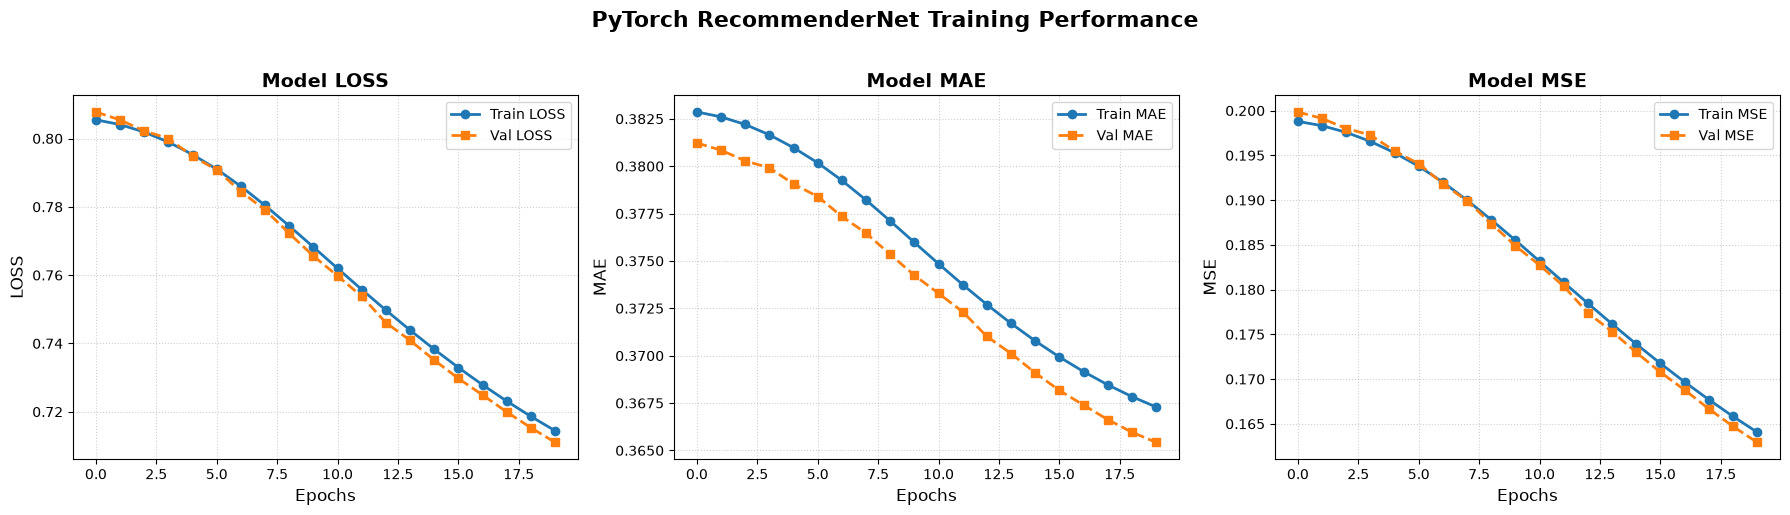

In [56]:
import matplotlib.pyplot as plt

# 1. Define the metrics to plot
metrics = ["loss", "mae", "mse"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2. Loop through each metric and plot train vs. validation curves
for i, metric in enumerate(metrics):
    axes[i].plot(history["loss" if metric == "loss" else metric], label=f"Train {metric.upper()}", marker='o', linewidth=2)
    axes[i].plot(history[f"val_{metric}"], label=f"Val {metric.upper()}", marker='s', linestyle='--', linewidth=2)
    
    axes[i].set_title(f"Model {metric.upper()}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Epochs", fontsize=12)
    axes[i].set_ylabel(metric.upper(), fontsize=12)
    axes[i].legend(loc="upper right", fontsize=10)
    axes[i].grid(True, linestyle=":", alpha=0.6)

plt.suptitle("PyTorch RecommenderNet Training Performance", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [65]:
anime_df = pd.read_csv(r"C:\Users\amann\Aman\Aman\MLOPS\Project-2\Anime_Recommender_System\artifacts\raw\anime[1].csv", low_memory=True)

In [66]:
anime_df.head()

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",Unknown,...,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",Trigun,トライガン,TV,26,"Apr 1, 1998 to Sep 30, 1998",Spring 1998,...,50229.0,75651.0,86142.0,49432.0,15376.0,5838.0,1965.0,664.0,316.0,533.0
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,26,"Jul 2, 2002 to Dec 24, 2002",Summer 2002,...,2182.0,4806.0,10128.0,11618.0,5709.0,2920.0,1083.0,353.0,164.0,131.0
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",Beet the Vandel Buster,冒険王ビィト,TV,52,"Sep 30, 2004 to Sep 29, 2005",Fall 2004,...,312.0,529.0,1242.0,1713.0,1068.0,634.0,265.0,83.0,50.0,27.0


In [67]:
anime_df = anime_df.replace("Unknown", np.nan)

In [70]:
def get_anime_name(anime_id):
    try:
        
        name = anime_df[anime_df.anime_id == anime_id].eng_version.values[0]
        if name is np.nan:
            name = anime_df[anime_df.anime_id == anime_id].Name.values[0]
    except:
        print("Error in getting the name")
    return name

In [71]:
anime_df["anime_id"] = anime_df["MAL_ID"]
anime_df["eng_version"] = anime_df["English name"]
anime_df["eng_version"] = anime_df["anime_id"].apply(lambda x: get_anime_name(x))

In [72]:
anime_df.head()

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1,anime_id,eng_version
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0,1,Cowboy Bebop
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",NaN,...,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0,5,Cowboy Bebop:The Movie
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",Trigun,トライガン,TV,26,"Apr 1, 1998 to Sep 30, 1998",Spring 1998,...,86142.0,49432.0,15376.0,5838.0,1965.0,664.0,316.0,533.0,6,Trigun
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,26,"Jul 2, 2002 to Dec 24, 2002",Summer 2002,...,10128.0,11618.0,5709.0,2920.0,1083.0,353.0,164.0,131.0,7,Witch Hunter Robin
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",Beet the Vandel Buster,冒険王ビィト,TV,52,"Sep 30, 2004 to Sep 29, 2005",Fall 2004,...,1242.0,1713.0,1068.0,634.0,265.0,83.0,50.0,27.0,8,Beet the Vandel Buster


In [74]:
anime_df.sort_values(by=["Score"],
                     inplace=True,
                     ascending=False,
                     kind="quicksort",
                     na_position="last"
                     )

In [75]:
anime_df.head(5)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1,anime_id,eng_version
3971,5114,Fullmetal Alchemist: Brotherhood,9.19,"Action, Military, Adventure, Comedy, Drama, Ma...",Fullmetal Alchemist:Brotherhood,鋼の錬金術師 FULLMETAL ALCHEMIST,TV,64,"Apr 5, 2009 to Jul 4, 2010",Spring 2009,...,199160.0,70045.0,20210.0,9308.0,3222.0,1536.0,2162.0,16806.0,5114,Fullmetal Alchemist:Brotherhood
15926,40028,Shingeki no Kyojin: The Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",Attack on Titan Final Season,進撃の巨人 The Final Season,TV,16,"Dec 7, 2020 to ?",Winter 2021,...,26016.0,8793.0,2674.0,1336.0,588.0,382.0,514.0,11061.0,40028,Attack on Titan Final Season
5683,9253,Steins;Gate,9.11,"Thriller, Sci-Fi",Steins;Gate,STEINS;GATE,TV,24,"Apr 6, 2011 to Sep 14, 2011",Spring 2011,...,140914.0,57740.0,21375.0,11126.0,5061.0,2292.0,1678.0,5255.0,9253,Steins;Gate
14963,38524,Shingeki no Kyojin Season 3 Part 2,9.1,"Action, Drama, Fantasy, Military, Mystery, Sho...",Attack on Titan Season 3 Part 2,進撃の巨人 Season3 Part.2,TV,10,"Apr 29, 2019 to Jul 1, 2019",Spring 2019,...,110481.0,33662.0,8365.0,2974.0,1108.0,550.0,385.0,4169.0,38524,Attack on Titan Season 3 Part 2
9913,28977,Gintama°,9.1,"Action, Comedy, Historical, Parody, Samurai, S...",Gintama Season 4,銀魂°,TV,51,"Apr 8, 2015 to Mar 30, 2016",Spring 2015,...,21360.0,10215.0,3898.0,2311.0,952.0,648.0,1100.0,4508.0,28977,Gintama Season 4


In [76]:
anime_df.columns

Index(['MAL_ID', 'Name', 'Score', 'Genres', 'English name', 'Japanese name',
       'Type', 'Episodes', 'Aired', 'Premiered', 'Producers', 'Licensors',
       'Studios', 'Source', 'Duration', 'Rating', 'Ranked', 'Popularity',
       'Members', 'Favorites', 'Watching', 'Completed', 'On-Hold', 'Dropped',
       'Plan to Watch', 'Score-10', 'Score-9', 'Score-8', 'Score-7', 'Score-6',
       'Score-5', 'Score-4', 'Score-3', 'Score-2', 'Score-1', 'anime_id',
       'eng_version'],
      dtype='str')

In [77]:
anime_df = anime_df[["anime_id", "eng_version", "Score", "Genres", "Episodes", "Type", "Premiered", "Members"]]

In [78]:
anime_df

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
3971,5114,Fullmetal Alchemist:Brotherhood,9.19,"Action, Military, Adventure, Comedy, Drama, Ma...",64,TV,Spring 2009,2248456
15926,40028,Attack on Titan Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",16,TV,Winter 2021,733260
5683,9253,Steins;Gate,9.11,"Thriller, Sci-Fi",24,TV,Spring 2011,1771162
14963,38524,Attack on Titan Season 3 Part 2,9.1,"Action, Drama, Fantasy, Military, Mystery, Sho...",10,TV,Spring 2019,1073626
9913,28977,Gintama Season 4,9.1,"Action, Comedy, Historical, Parody, Samurai, S...",51,TV,Spring 2015,404121
...,...,...,...,...,...,...,...,...
17557,48481,Daomu Biji Zhi Qinling Shen Shu,NaN,"Adventure, Mystery, Supernatural",NaN,ONA,NaN,354
17558,48483,Mieruko-chan,NaN,"Comedy, Horror, Supernatural",NaN,TV,NaN,7010
17559,48488,Higurashi:When They Cry – SOTSU,NaN,"Mystery, Dementia, Horror, Psychological, Supe...",NaN,TV,Summer 2021,11309
17560,48491,Yama no Susume: Next Summit,NaN,"Adventure, Slice of Life, Comedy",NaN,TV,NaN,1386


In [79]:
def get_anime(anime, anime_df):
    if isinstance(anime, int):
        return anime_df[anime_df.anime_id == anime]
    if isinstance(anime, str):
        return anime_df[anime_df.eng_version == anime]

In [80]:
get_anime(40028, anime_df)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
15926,40028,Attack on Titan Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",16,TV,Winter 2021,733260


In [81]:
get_anime("Gintama Season 4", anime_df)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
9913,28977,Gintama Season 4,9.1,"Action, Comedy, Historical, Parody, Samurai, S...",51,TV,Spring 2015,404121


In [82]:
synopsis_df = pd.read_csv(r"C:\Users\amann\Aman\Aman\MLOPS\Project-2\Anime_Recommender_System\artifacts\raw\anime_with_synopsis[1].csv", low_memory=True)

In [93]:
synopsis_df

,MAL_ID,Name,Score,Genres,sypnopsis
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space","In the year 2071, humanity has colonized sever..."
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space","other day, another bounty—such is the life of ..."
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen","Vash the Stampede is the man with a $$60,000,0..."
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",ches are individuals with special powers like ...
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",It is the dark century and the people are suff...
...,...,...,...,...,...
16209,48481,Daomu Biji Zhi Qinling Shen Shu,Unknown,"Adventure, Mystery, Supernatural",No synopsis information has been added to this...
16210,48483,Mieruko-chan,Unknown,"Comedy, Horror, Supernatural",ko is a typical high school student whose life...
16211,48488,Higurashi no Naku Koro ni Sotsu,Unknown,"Mystery, Dementia, Horror, Psychological, Supe...",Sequel to Higurashi no Naku Koro ni Gou .
16212,48491,Yama no Susume: Next Summit,Unknown,"Adventure, Slice of Life, Comedy",New Yama no Susume anime.


In [87]:
def get_synopsis(anime, df):
    if isinstance(anime, int):
        return df[df.MAL_ID == anime].sypnopsis.values[0]
    if isinstance(anime, str):
        return df[df.Name == anime].sypnopsis.values[0]

In [88]:
get_synopsis(40028, synopsis_df)

"Gabi Braun and Falco Grice have been training their entire lives to inherit one of the seven titans under Marley's control and aid their nation in eradicating the Eldians on Paradis. However, just as all seems well for the two cadets, their peace is suddenly shaken by the arrival of Eren Yeager and the remaining members of the Survey Corps. Having finally reached the Yeager family basement and learned about the dark history surrounding the titans, the Survey Corps has at long last found the answer they so desperately fought to uncover. With the truth now in their hands, the group set out for the world beyond the walls. In Shingeki no Kyojin: The Final Season , two utterly different worlds collide as each party pursues its own agenda in the long-awaited conclusion to Paradis' fight for freedom."

In [94]:
get_synopsis(28977, synopsis_df)

"Gintoki, Shinpachi, and Kagura return as the fun-loving but broke members of the Yorozuya team! Living in an alternate-reality Edo, where swords are prohibited and alien overlords have conquered Japan, they try to thrive on doing whatever work they can get their hands on. However, Shinpachi and Kagura still haven't been paid... Does Gin-chan really spend all that cash playing pachinko? Meanwhile, when Gintoki drunkenly staggers home one night, an alien spaceship crashes nearby. A fatally injured crew member emerges from the ship and gives Gintoki a strange, clock-shaped device, warning him that it is incredibly powerful and must be safeguarded. Mistaking it for his alarm clock, Gintoki proceeds to smash the device the next morning and suddenly discovers that the world outside his apartment has come to a standstill. With Kagura and Shinpachi at his side, he sets off to get the device fixed; though, as usual, nothing is ever that simple for the Yorozuya team. Filled with tongue-in-cheek

In [96]:
pd.set_option("max_colwidth", None)

In [126]:
def get_similar_anime(name, anime_weights, anime2anime_encoded, anime2anime_decoded, anime_df, synopsis_df, n=10, return_dist = False, neg = False):
    try:
        index = get_anime(name, anime_df).anime_id.values[0]
        encoded_index = anime2anime_encoded[index]
        
        weights = anime_weights
        
        dists = np.dot(weights, weights[encoded_index])
        sorted_dists = np.argsort(dists)
        
        n = n + 1
        
        if neg:
            closest = sorted_dists[ : n]
        else:
            closest = sorted_dists[-n : ]
            
        if return_dist:
            return dists, closest
        
        similarity_array = []
        
        for close in closest:
            decoded_id = anime2anime_decoded[close]
            
            synopsis = get_synopsis(decoded_id, synopsis_df)
            anime_frame = get_anime(decoded_id, anime_df)
            
            anime_name = anime_frame.eng_version.values[0]
            genre = anime_frame.Genres.values[0]
            similarity = dists[close]
            
            similarity_array.append({
                "anime_id" : decoded_id,
                "name" : anime_name,
                "similarity": similarity,
                "genre": genre,
                "synopsis": synopsis
            })
        
        Frame = pd.DataFrame(similarity_array).sort_values(by="similarity", ascending=False)
        return Frame[Frame.anime_id != index].drop(["anime_id"], axis=1)
    
    except Exception as e:
        print("Error occurred", e)

In [129]:
dists, closest = get_similar_anime("Bleach", anime_weights, anime2anime_encoded, anime2anime_decoded, anime_df, synopsis_df, return_dist=True)

In [131]:
closest

array([14483,  3255,  9183,  5745, 15939,  8505, 11852, 13354, 16421,
       17055,   820])

In [139]:
def get_similar_users(item_name, user_weights, user2user_encoded, user2user_decoded, n=10, return_dist=False, neg = False):
    try:
        index = item_name
        encoded_index = user2user_encoded[index]
        
        weights = user_weights
        
        dists = np.dot(weights, user_weights[encoded_index])
        sorted_dists = np.argsort(dists)
        
        n = n + 1
        
        if neg:
            closest = sorted_dists[ : n]
        else:
            closest = sorted_dists[-n : ]
        
        if return_dist:
            return dists, closest
        
        Similarity_array = []

        for close in closest:
            similarity = dists[close]
            if isinstance(item_name, int):
                decoded_id = user2user_decoded[close]
                Similarity_array.append({
                    "user_id": decoded_id,
                    "similarity": similarity
                })
        
        Frame = pd.DataFrame(Similarity_array).sort_values(by="similarity", ascending=False)
        return Frame[Frame.user_id != item_name]
    
    except Exception as e:
        print("Error occurred", e)
            

In [140]:
get_similar_users(int(11880), user_weights, user2user_encoded, user2user_decoded)

,user_id,similarity
9,16431,0.301927
8,6359,0.274068
7,14287,0.271374
6,2868,0.269626
5,12797,0.254330
4,815,0.252547
3,3531,0.251961
2,4325,0.247916
1,9154,0.245113
0,14487,0.238984


In [ ]:
import wordcloud

def showWordCloud():
    pass

In [143]:
frame = get_anime(1, anime_df)

In [145]:
from collections import defaultdict

def get_fav_genre(frame, plot = False):
    frame.dropna(inplace=False)
    all_genre = defaultdict(int)
    genre_list = []
    
    for genres in frame["Genres"]:
        if isinstance(genres, str):
            for genre in genres.split(','):
                genre_list.append(genre.strip())
                all_genre[genre.strip()] += 1
                
    if plot:
        return showWordCloud
    
    return genre_list
    

In [146]:
get_fav_genre(frame)

['Action', 'Adventure', 'Comedy', 'Drama', 'Sci-Fi', 'Space']

In [167]:
def get_user_preferences(user_id, rating_df, anime_df, plot = False):
    
    anime_watched_by_user = rating_df[rating_df.user_id == user_id]
    
    user_rating_percentile = np.percentile(anime_watched_by_user.rating, 75)
    
    anime_watched_by_user = anime_watched_by_user[anime_watched_by_user.rating >= user_rating_percentile]
    
    top_anime_user = (
        anime_watched_by_user.sort_values(by="rating", ascending = False).anime_id.values
    )
    
    anime_df_rows = anime_df[anime_df["anime_id"].isin(top_anime_user)]
    anime_df_rows = anime_df_rows[["eng_version","Genres"]]
    
    if plot:
        get_fav_genre(anime_df_rows, plot)
    
    return anime_df_rows

In [168]:
get_user_preferences(11880, rating_df, anime_df)

,eng_version,Genres
3971,Fullmetal Alchemist:Brotherhood,"Action, Military, Adventure, Comedy, Drama, Magic, Fantasy, Shounen"
9913,Gintama Season 4,"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen"
6474,Hunter x Hunter,"Action, Adventure, Fantasy, Shounen, Super Power"
6006,Gintama Season 2,"Action, Sci-Fi, Comedy, Historical, Parody, Samurai, Shounen"
741,Legend of the Galactic Heroes,"Military, Sci-Fi, Space, Drama"
...,...,...
2575,Shootfighter Tekken,"Action, Martial Arts, Shounen"
8064,Samurai Flamenco,"Action, Comedy, Parody, Super Power"
510,Venus Wars,"Action, Sci-Fi, Adventure, Space"
6864,Saint Seiya Omega,"Action, Adventure, Fantasy, Shounen"


In [ ]:
def user_based_recommendation(similar_users, user_pref, anime_df, synopsis_df, plot = False):
    

np.float64(0.9)